RQ4 Plot: ../../../results/ablation_combined_1x2_icde.pdf


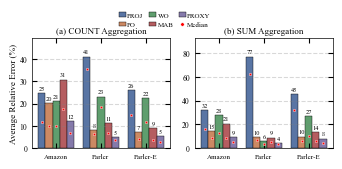

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from matplotlib.ticker import FuncFormatter


TARGET_BUDGET = 0.1  
Y_SCALE = "linear"  

BAR_TEXT_FONTSIZE = 4.5      
ROUND_TO_INT = True          

DATASETS_CONFIG = {
    "Parler": {"base_dir": "/home/wangshuo/projects/PROXY/datasets/parler/results"},
    "Parler-E": {"base_dir": "/home/wangshuo/projects/PROXY/datasets/parler-E/results"},
    "Amazon": {"base_dir": "/home/wangshuo/projects/PROXY/datasets/amazon/results"}
}

METHOD_MAP = {"UN": "PROJ", "PO": "PO", "WO": "WO", "MAB": "MAB", "8_POSSA": "PROXY", "POSS": "PROXY"}
DISPLAY_ORDER = ["PROJ", "PO", "WO", "MAB", "PROXY"]

out_dir = "../../../results/"
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, "ablation_combined_1x2_icde.pdf") 


plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",             
    "font.serif": ["Times New Roman"],  
    "mathtext.fontset": "stix",         
    "font.size": 6.0,                   
    "axes.labelsize": 6.5,
    "axes.titlesize": 6.5,              
    "legend.fontsize": 5.0,             
    "xtick.labelsize": 5.0,             
    "ytick.labelsize": 5.5,
    "axes.linewidth": 0.5,
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "lines.linewidth": 0.8
})


def load_data_for_mode(agg_mode):
    all_records = []
    csv_name = f"allocation_strategy_comparison_ablation_{agg_mode}.csv"
    
    for display_name, config in DATASETS_CONFIG.items():
        base_dir = config["base_dir"]
        json_name = f"T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
        
        if display_name == "Amazon":
            json_name = f"T_true_ML3_oracle2_probability_ML2_oracle1_probability_{agg_mode}.json"
            
        csv_path = os.path.join(base_dir, "efficiency", csv_name)
        json_path = os.path.join(base_dir, json_name)
        
        if not os.path.exists(csv_path) or not os.path.exists(json_path):
            continue
            
        with open(json_path, 'r') as f:
            t_true_map = {k.replace(".graph", ""): float(v) for k, v in json.load(f).items()}
        
        df = pd.read_csv(csv_path)
        if "budget_frac" in df.columns:
            df = df[np.isclose(df["budget_frac"], TARGET_BUDGET)].copy()
            
        df["method_display"] = df["method"].map(METHOD_MAP)
        df = df.dropna(subset=["method_display"]) 
        df["T_true"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True).map(t_true_map)
        df = df[df["T_true"].notna() & (df["T_true"] > 0)].copy()
        
        df["ARE"] = (df["T_hat"].astype(float) - df["T_true"]).abs() / (df["T_true"] + 1e-9)
        grouped = df.groupby("method_display")["ARE"].agg(['mean', 'median']).reset_index()
        
        for _, row in grouped.iterrows():
            all_records.append({
                "Dataset": display_name, "Method": row["method_display"],
                "AAE": row["mean"] * 100, "Median_AAE": row["median"] * 100 
            })
            
    df_plot = pd.DataFrame(all_records)
    if not df_plot.empty:
        df_plot["Method"] = pd.Categorical(df_plot["Method"], categories=DISPLAY_ORDER, ordered=True)
        df_plot = df_plot.sort_values(["Dataset", "Method"])
    return df_plot

fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.6), sharey=False)
palette = sns.color_palette("deep", n_colors=len(DISPLAY_ORDER))

modes = ['count', 'sum']
titles = ['(a) COUNT Aggregation', '(b) SUM Aggregation']

for idx, mode in enumerate(modes):
    ax = axes[idx]
    df_plot = load_data_for_mode(mode)
    
    if df_plot.empty:
        ax.set_title(f"No Data for {mode}")
        continue

    sns.barplot(
        data=df_plot, x="Dataset", y="AAE", hue="Method", hue_order=DISPLAY_ORDER, 
        palette=palette, edgecolor="black", linewidth=0.3, ax=ax
    )

    ax.set_title(titles[idx], pad=3)
    ax.set_xlabel("")  
    
    ax.grid(axis='y', which='major', linestyle='--', alpha=0.3, color='gray')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}')) 
    
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.tick_params(direction='in', which='both', top=True, right=True, colors='black')
    
    if idx == 0:

        ax.set_ylabel("Average Relative Error (%)", color='black', labelpad=1) 
    else:
        ax.set_ylabel("") 
        
    ymin, ymax = ax.get_ylim()
    
    ax.set_ylim(0, ymax * 1.15) 

    ax.get_legend().remove()

    datasets_order = df_plot["Dataset"].unique()
    for i, container in enumerate(ax.containers):
        method_name = DISPLAY_ORDER[i]
        for j, bar in enumerate(container):
            height = bar.get_height()
            if pd.isna(height) or height <= 0: continue
                
            x_pos = bar.get_x() + bar.get_width() / 2
            dataset_name = datasets_order[j]
            median_val = df_plot[(df_plot["Method"] == method_name) & (df_plot["Dataset"] == dataset_name)]["Median_AAE"].values[0]

            ax.plot(x_pos, median_val, marker='o', color='red', markersize=1.8, zorder=3, markeredgecolor='white', markeredgewidth=0.3)
            
            text_str = f'{int(round(height))}' if ROUND_TO_INT else f'{height:.1f}'

            ax.annotate(text_str, xy=(x_pos, height), xytext=(0, 1.5), textcoords="offset points",
                        ha='center', va='bottom', fontsize=BAR_TEXT_FONTSIZE, color='black', rotation=0)

    ax.tick_params(axis='x', rotation=0, colors='black')

handles, labels = axes[0].get_legend_handles_labels()
handles.append(mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=2.5, markeredgecolor='white', markeredgewidth=0.3))
labels.append('Median')

fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
           ncol=3, frameon=False, columnspacing=0.8, handletextpad=0.2, handlelength=1.0)

plt.subplots_adjust(wspace=0.18, top=0.85, bottom=0.16, left=0.12, right=0.98)

fig.savefig(out_pdf, format="pdf", bbox_inches="tight", dpi=300)
print(f"RQ4 Plot: {out_pdf}")
plt.show()